In [1]:
# Para tratamiento de datos
import polars as pl
import math
# Para visualizaciones
import seaborn as sns 
import matplotlib.pyplot as plt
# Para gestión de fechas
from datetime import datetime
# Para conectar a la base de datos
import psycopg2
# Cargar variables de entorno
import os
from dotenv import load_dotenv
# Configuracion de Polars para mostrar todas las columnas y hasta 25 filas
pl.Config.set_tbl_rows(25)  # Asegura que se muestren hasta 1000 filas
pl.Config.set_tbl_width_chars(500)  # Aumenta el ancho para evitar cortes
# importamos funciones de soporte
from src import funciones_load as fl
from src import funciones_eda as feda

In [2]:
conexion = os.getenv("conexion_bbdd")
madrid_18 = feda.obtener_datos_madrid(conexion, 2018, 2018, "Madrid")

Conexión establecida y consulta de prueba exitosa.


In [3]:
df_mensual, estaciones, contaminantes = feda.preproceso_datos(madrid_18)

Usamos matplotlib para reprentar los valores mensuales medios de cada contaminante en cada estación. Hay un total de 24 estaciones, por lo que vamos a hacer subplots. Se miden 14 contaminantes así que vamos a crear una leyenda única para todos los subplots.

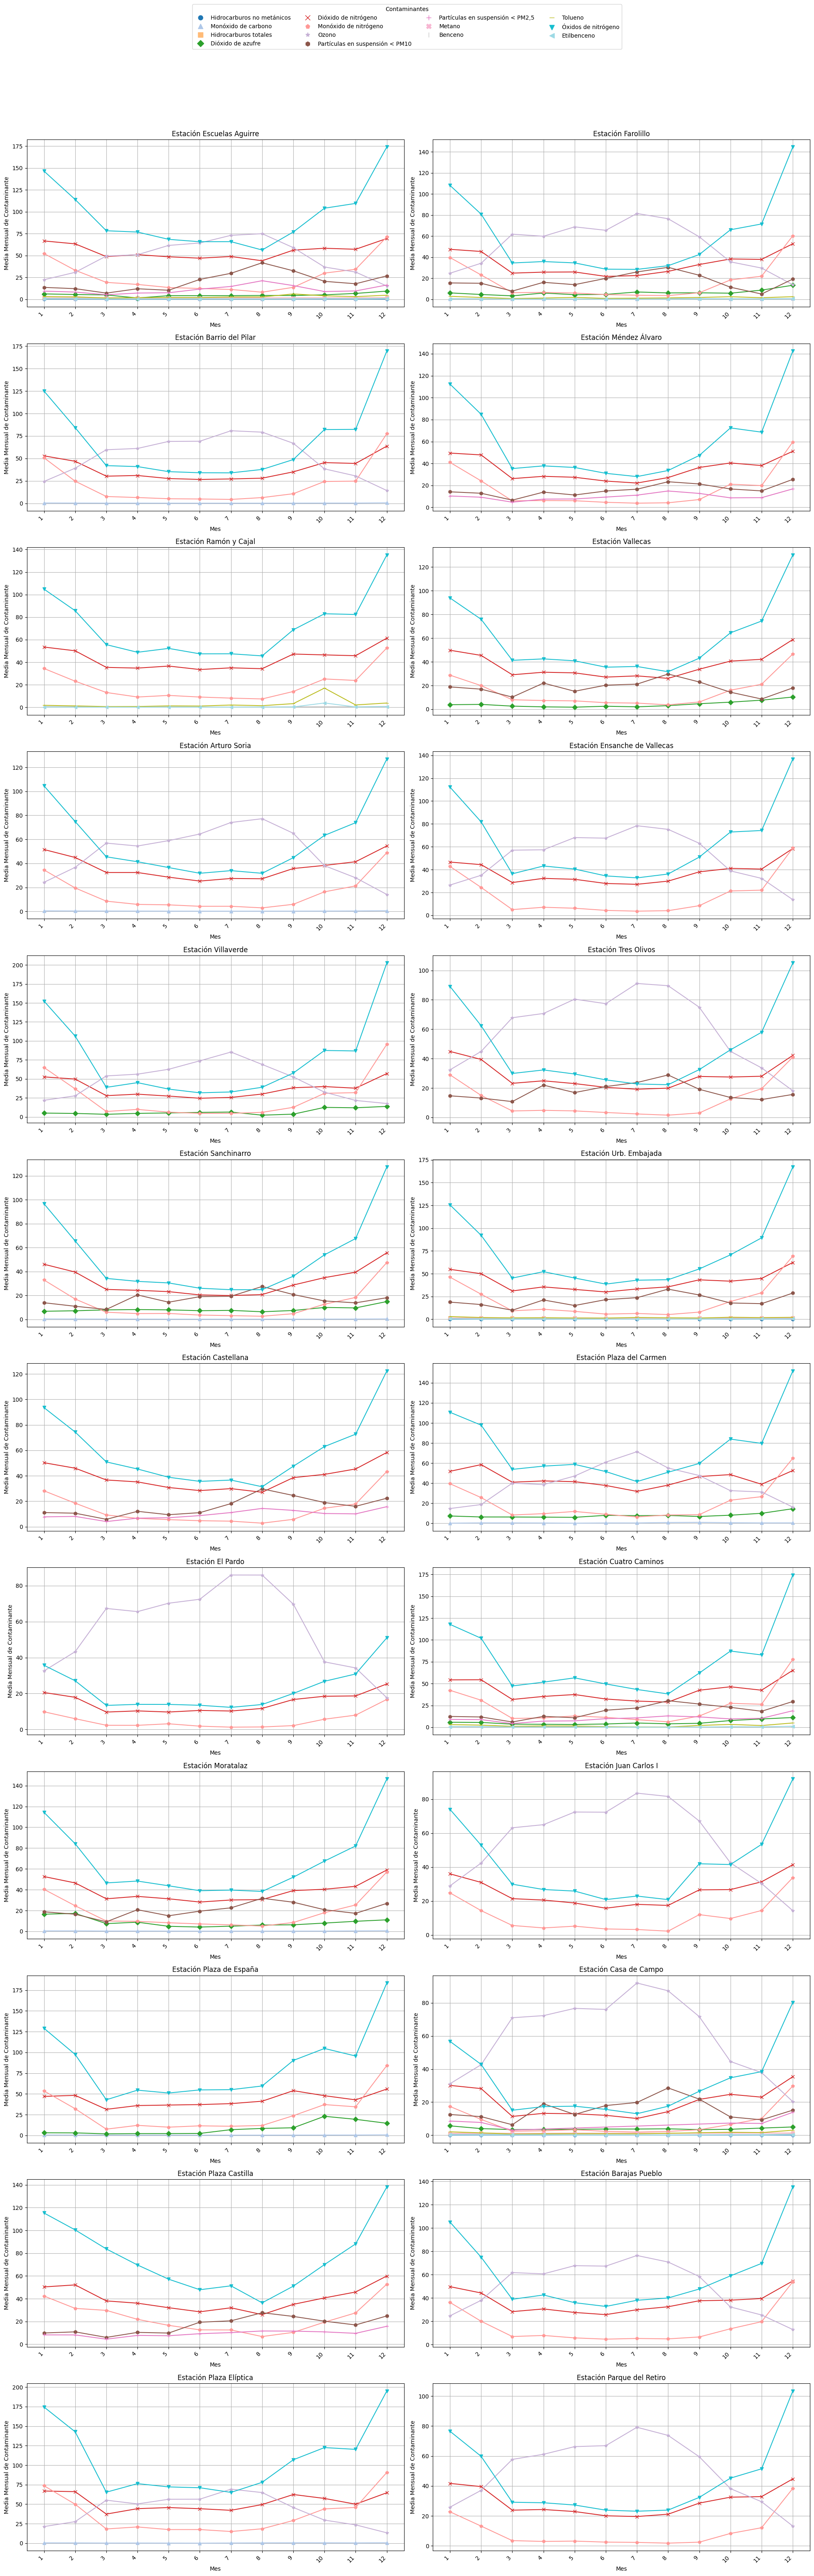

In [4]:
feda.graficos_estaciones(df_mensual, estaciones, contaminantes)

A primera vista, podemos ver que no todas las estaciones miden los mismos contaminantes. Los básicos que miden todas las estaciones son Monóxido de nitrógeno, Óxidos de nitrógeno y Dióxido de nitrógeno, por lo que empezaremos comparando estos contaminantes.

In [7]:
contaminantes_por_estacion = (
    madrid_18.group_by("contaminante")
    .agg(pl.col("estacion").n_unique().alias("num_estaciones"))
    .sort("num_estaciones", descending=True)  # Opcional, para ordenar de mayor a menor
)
contaminantes_por_estacion

contaminante,num_estaciones
str,u32
"""Monóxido de nitrógeno""",24
"""Dióxido de nitrógeno""",24
"""Óxidos de nitrógeno""",24
"""Ozono""",14
"""Partículas en suspensión < PM1…",12
"""Monóxido de carbono""",10
"""Dióxido de azufre""",10
"""Tolueno""",6
"""Etilbenceno""",6


Los **Óxidos de nitrógeno** siguen un patrón muy similar en todas las estaciones, con un descenso marcado de enero a marzo, una cierta estabilidad ente marzo y agosto u otra fuerte subida hasta diciembre, superando en todos los casos el valor de enero. Además, salvo algunas excepciones es el contaminante que alcanza mayores valores, por lo que habría que prestar atención si se mantiene así el resto de años del análisis.  
El **Dióxido de nitrógeno** sigue un patrón similar al de los óxidos de nitrógeno, pero sin alcanzar valores tan altos, aunque sigue siendo el segundo contaminante más alto, salvo las mismas excepciones que el caso anterior, en las que el ozono tiene una tendencia opuesta, como veremos más adelante.  
El **Monóxido de nitrógeno** también tiene ese patrón aunque con valores más bajos, picos en enero y diciembre y un valle más estable entre marzo y agosto.
Esto puede sugerir una relación con el encendido de las calefacciones en los meses fríos.  
El **Ozono**, se mide en 14 de las 24 estaciones y, en las estaciones que lo miden tiene un patrón opuesto al de todos los óxidos de nitrógeno: mínimos en enero y diciembre y máximos en torno a julio - agosto.  Además los máximos en algunos casos superan los máximos de óxidos de nitrógeno.
El siguiente que aparece en más estaciones es **Partículas en suspensión < PM10** que en este año presenta un pico en agosto. Dado que estas partículas suelen proceder de fenónemos naturales, es posible que ese año hubiera polvo del desierto del Sáhara.
El **monóxido de carbono** se mide en 10 estaciones aunque parece tener un valor muy cercano a 0 en todas las estaciones todo el año.
El **dióxido de azufre** también se mide en 10 estaciones y aunque se mantiene relativamente en niveles bajos y estables durante todo el año, en algunas estaciones presenta cierta subida hacia final de año.
